# ResNet50 — Experiment 3: Fine-Tuning
Loads best Exp2 model, unfreezes last 30 backbone layers, retrains with very small LR.

In [1]:
import os, re, json
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight

TRAIN_DIR = "/kaggle/input/datasets/usmanafzaal/strawberry-disease-detection-dataset/train"
VAL_DIR   = "/kaggle/input/datasets/usmanafzaal/strawberry-disease-detection-dataset/val"
TEST_DIR  = "/kaggle/input/datasets/usmanafzaal/strawberry-disease-detection-dataset/test"

CLASS_NAMES = [
    'Angular Leafspot',
    'Anthracnose Fruit Rot',
    'Blossom Blight',
    'Gray Mold',
    'Leaf Spot',
    'Powdery Mildew Fruit',
    'Powdery Mildew Leaf'
]

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS_FT  = 15
LR_FT      = 1e-5     # Small LR — critical for fine-tuning
UNFREEZE_N = 30       # Unfreeze last 30 backbone layers
SEED       = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
print('Setup done.')

2026-03-11 02:12:08.422236: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773195128.601992      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773195128.652151      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773195129.108357      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773195129.108404      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773195129.108406      24 computation_placer.cc:177] computation placer alr

Setup done.


In [2]:
# ── Load ResNet50 Exp2 Model ────────────────────────────

model = tf.keras.models.load_model(
    '/kaggle/input/notebooks/elaffa/06-resnet50-exp2-augmentation/resnet_exp2.keras'
)
print('ResNet50 Exp2 model loaded.')
model.summary()

I0000 00:00:1773195154.432953      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773195154.439117      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


ResNet50 Exp2 model loaded.


Model: "ResNet50_Exp2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │        14,343 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,647,127 (90.21 MB)

 Trainable params: 18,439 (72.03 KB)

 Non-trainable params: 23,591,808 (90.00 MB)

 Optimizer params: 36,880 (144.07 KB)

In [3]:
# ── Load Labels from JSON ───────────────────────────────
def load_split(folder):
    data = []
    for f in os.listdir(folder):
        if not f.lower().endswith('.jpg'):
            continue
        img_path  = os.path.join(folder, f)
        json_path = img_path.replace('.jpg', '.json')
        label = None
        if os.path.exists(json_path):
            try:
                with open(json_path) as jf:
                    ann = json.load(jf)
                shapes = ann.get('shapes', [])
                if shapes:
                    label = shapes[0].get('label', None)
            except:
                pass
        if not label:
            name = os.path.splitext(f)[0]
            label = re.sub(r'\d+$', '', name).strip()
        data.append([img_path, label])
    return pd.DataFrame(data, columns=['path', 'label'])

train_df = load_split(TRAIN_DIR)
val_df   = load_split(VAL_DIR)
test_df  = load_split(TEST_DIR)

label2idx   = {name: i for i, name in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)

for df in (train_df, val_df, test_df):
    df['label_idx'] = df['label'].map(label2idx)

weights = compute_class_weight('balanced',
                                classes=np.arange(NUM_CLASSES),
                                y=train_df['label_idx'].values)
class_weight_dict = dict(enumerate(weights))
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

Train: 1450 | Val: 307 | Test: 743


In [4]:
# ── tf.data Pipeline ────────────────────────────────────
preprocess = tf.keras.applications.resnet50.preprocess_input

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    img = preprocess(img)
    return img, label

def make_dataset(df, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (df['path'].values, df['label_idx'].values))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED)
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, shuffle=True)
val_ds   = make_dataset(val_df)
test_ds  = make_dataset(test_df)
print('Datasets ready.')

Datasets ready.


In [5]:
# ── Unfreeze Last N Backbone Layers ─────────────────────
backbone = None
for layer in model.layers:
    if isinstance(layer, tf.keras.Model):
        backbone = layer
        break

print(f'Backbone: {backbone.name} ({len(backbone.layers)} layers)')

backbone.trainable = True
for layer in backbone.layers[:-UNFREEZE_N]:
    layer.trainable = False

trainable = sum(l.trainable for l in backbone.layers)
print(f'Trainable backbone layers: {trainable} / {len(backbone.layers)}')

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_FT),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Backbone: augmentation (5 layers)
Trainable backbone layers: 5 / 5


In [6]:
# ── Fine-Tune ───────────────────────────────────────────
callbacks_ft = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5,
        restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=2, min_lr=1e-7, verbose=1),
]

history3 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FT,
    callbacks=callbacks_ft,
    class_weight=class_weight_dict
)

Epoch 1/15


I0000 00:00:1773195183.386685      67 cuda_dnn.cc:529] Loaded cuDNN version 91002


46/46 ━━━━━━━━━━━━━━━━━━━━ 24s 235ms/step - accuracy: 0.9368 - loss: 0.2008 - val_accuracy: 0.9283 - val_loss: 0.2222 - learning_rate: 1.0000e-05
Epoch 2/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 152ms/step - accuracy: 0.9492 - loss: 0.1768 - val_accuracy: 0.9283 - val_loss: 0.2304 - learning_rate: 1.0000e-05
Epoch 3/15
45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.9298 - loss: 0.2328
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 153ms/step - accuracy: 0.9298 - loss: 0.2319 - val_accuracy: 0.9283 - val_loss: 0.2359 - learning_rate: 1.0000e-05
Epoch 4/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 152ms/step - accuracy: 0.9411 - loss: 0.1967 - val_accuracy: 0.9251 - val_loss: 0.2420 - learning_rate: 5.0000e-06
Epoch 5/15
45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.9366 - loss: 0.2000
Epoch 5: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 153ms/step - accuracy: 0.9366 - loss: 0.199

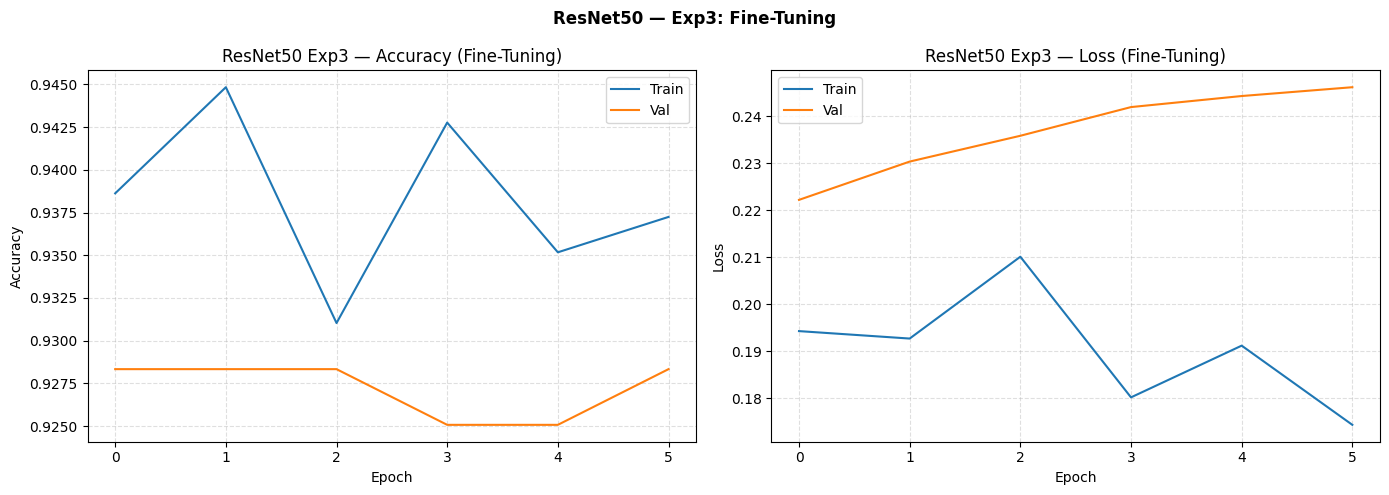

In [7]:
# ── Training Curves ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history3.history['accuracy'],     label='Train')
axes[0].plot(history3.history['val_accuracy'], label='Val')
axes[0].set_title('ResNet50 Exp3 — Accuracy (Fine-Tuning)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(linestyle='--', alpha=0.4)

axes[1].plot(history3.history['loss'],     label='Train')
axes[1].plot(history3.history['val_loss'], label='Val')
axes[1].set_title('ResNet50 Exp3 — Loss (Fine-Tuning)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(linestyle='--', alpha=0.4)

plt.suptitle('ResNet50 — Exp3: Fine-Tuning', fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/resnet_exp3_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ── Evaluate on Test Set ────────────────────────────────
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f'[ResNet50 Exp3] Test Loss    : {test_loss:.4f}')
print(f'[ResNet50 Exp3] Test Accuracy: {test_acc:.4f}')

y_true = np.concatenate([y for _, y in test_ds], axis=0)
y_prob = model.predict(test_ds)
y_pred = np.argmax(y_prob, axis=1)

print('\n[ResNet50 Exp3] Classification Report:')
print(classification_report(y_true, y_pred,
      target_names=CLASS_NAMES, digits=4, zero_division=0))

[ResNet50 Exp3] Test Loss    : 0.3818
[ResNet50 Exp3] Test Accuracy: 0.8668
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 197ms/step

[ResNet50 Exp3] Classification Report:
                       precision    recall  f1-score   support

     Angular Leafspot     0.8313    0.9048    0.8664       147
Anthracnose Fruit Rot     0.5526    0.6176    0.5833        34
       Blossom Blight     1.0000    1.0000    1.0000        62
            Gray Mold     0.8253    0.9448    0.8810       145
            Leaf Spot     0.9545    0.7826    0.8601       161
 Powdery Mildew Fruit     0.5405    0.4651    0.5000        43
  Powdery Mildew Leaf     0.9797    0.9603    0.9699       151

             accuracy                         0.8668       743
            macro avg     0.8120    0.8107    0.8087       743
         weighted avg     0.8715    0.8668    0.8659       743



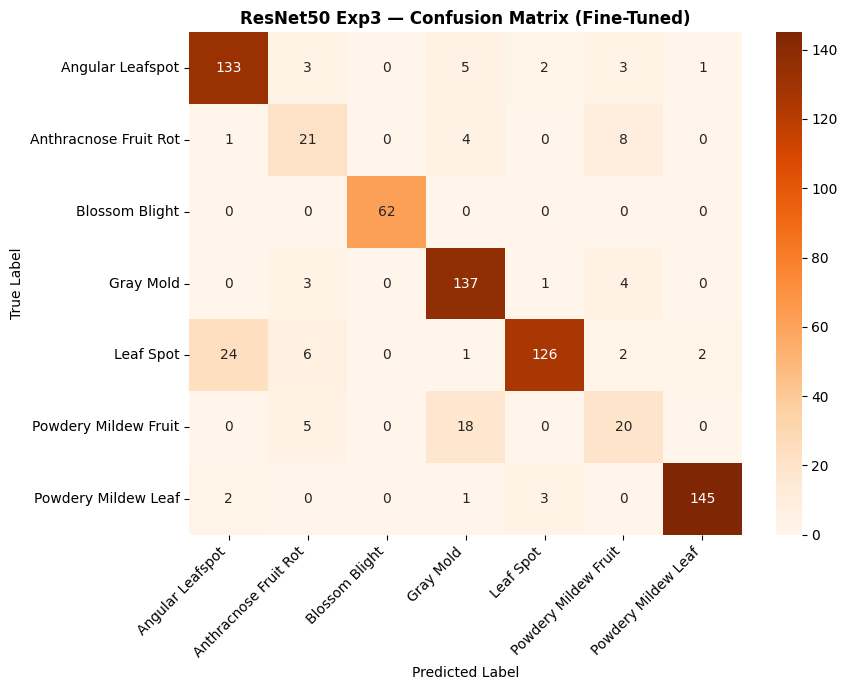

In [9]:
# ── Confusion Matrix ────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('ResNet50 Exp3 — Confusion Matrix (Fine-Tuned)', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/kaggle/working/resnet_exp3_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ── Save Model + Results CSV ────────────────────────────
model.save('/kaggle/working/resnet_exp3_finetuned.keras')

exp3_results = {
    'experiment' : 'Exp3 - Fine-Tuned',
    'model'      : 'ResNet50',
    'test_acc'   : round(float(test_acc), 4),
    'test_loss'  : round(float(test_loss), 4),
    'f1_weighted': round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4),
    'precision'  : round(precision_score(y_true, y_pred, average='weighted', zero_division=0), 4),
    'recall'     : round(recall_score(y_true, y_pred, average='weighted', zero_division=0), 4),
}
pd.DataFrame([exp3_results]).to_csv('/kaggle/working/resnet_exp3_results.csv', index=False)
print('Model and results saved!')
print(exp3_results)

Model and results saved!
{'experiment': 'Exp3 - Fine-Tuned', 'model': 'ResNet50', 'test_acc': 0.8668, 'test_loss': 0.3818, 'f1_weighted': 0.8659, 'precision': 0.8715, 'recall': 0.8668}
